# 05. Detección no supervisada (Fase 4, pregunta 3)

**Pregunta:** ¿un modelo entrenado únicamente con tráfico normal puede señalar como
"anómalos" los ataques, sin haber visto nunca un ataque etiquetado?

**Por qué es importante:** un clasificador supervisado solo detecta lo que vio en el
entrenamiento. Un detector de anomalías funciona al revés, marca lo que se ve *raro*
aunque sea un ataque nuevo. Por eso es el complemento natural del modelo supervisado.

**Montaje** (el cómputo está en `python -m src.no_supervisado`, con checkpoints; este
notebook solo lee los CSVs de `reports/resultados_fase4/`):

- **Entrenamiento:** los 394.236 flujos benignos del **lunes** (el único día sin ataques)
  que quedaron en el conjunto de entrenamiento. El escalado se ajusta solo con ellos y el
  conjunto de prueba sigue intacto.
- **Evaluación:** el resto del entrenamiento (de martes a viernes: 1.604.226 flujos, de
  los cuales 340.593 son de ataque, de todos los tipos, incluidos Heartbleed e
  Infiltration, que el multiclase supervisado tuvo que excluir).
- **Modelos:** Isolation Forest (el principal) y Local Outlier Factor (como contraste,
  entrenado con una submuestra de 50.000 flujos por su costo de predicción).
- **Umbral:** los cuantiles 0,5% / 1% / 2% de los scores del propio lunes (equivale al
  parámetro de contaminación). El de referencia es el 1%.

**Advertencia (limitación documentada):** la literatura reporta errores de etiquetado
en CIC-IDS2017 (Engelen 2021; Lanvin 2023), así que parte del "benigno" del lunes podría
contener ataques sin etiquetar y contaminar el entrenamiento. El umbral por cuantiles
tiene en cuenta esa posible contaminación de forma explícita.

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RUTA_FIGURAS
from src.no_supervisado import RUTA_EXPORT

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

recall = pd.read_csv(RUTA_EXPORT / "q3_recall_por_ataque.csv")
falsas = pd.read_csv(RUTA_EXPORT / "q3_falsas_alarmas_por_dia.csv")
scores = pd.read_csv(RUTA_EXPORT / "q3_scores_muestra.csv")
print("Resultados cargados")

Resultados cargados


## 1. ¿Qué ataques marca como anómalos? (recall por tipo)

In [2]:
tabla_recall = recall.pivot_table(
    index=["modelo", "clase"], columns="umbral_pct", values="recall"
).round(3)
tabla_recall.columns = [f"umbral {c}%" for c in tabla_recall.columns]
tabla_recall

umbral 0.5%  umbral 1.0%  umbral 2.0%
modelo  clase                                                            
iforest Bot                               0.000        0.000        0.000
        DDoS                              0.002        0.034        0.062
        DoS GoldenEye                     0.002        0.004        0.009
        DoS Hulk                          0.008        0.244        0.270
        DoS Slowhttptest                  0.066        0.140        0.768
        DoS slowloris                     0.504        0.520        0.549
        FTP-Patator                       0.000        0.000        0.000
        Heartbleed                        0.778        0.889        1.000
        Infiltration                      0.207        0.483        0.793
        PortScan                          0.000        0.000        0.001
        SSH-Patator                       0.000        0.000        0.000
        TODOS LOS ATAQUES                 0.011        0.118        0.145
        Web Attack - Brute Force          0.000        0.000        0.000
        Web Attack - Sql Injection        0.000        0.000        0.000
        Web Attack - XSS                  0.000        0.000        0.000
lof     Bot                               0.001        0.001        0.001
        DDoS                              0.000        0.000        0.191
        DoS GoldenEye                     0.128        0.134        0.183
        DoS Hulk                          0.001        0.002        0.022
        DoS Slowhttptest                  0.009        0.009        0.064
        DoS slowloris                     0.000        0.000        0.004
        FTP-Patator                       0.000        0.000        0.000
        Heartbleed                        0.000        0.000        0.000
        Infiltration                      0.000        0.000        0.172
        PortScan                          0.013        0.112        0.548
        SSH-Patator                       0.000        0.906        0.937
        TODOS LOS ATAQUES                 0.006        0.035        0.195
        Web Attack - Brute Force          0.000        0.008        0.013
        Web Attack - Sql Injection        0.000        0.000        0.000
        Web Attack - XSS                  0.000        0.000        0.000

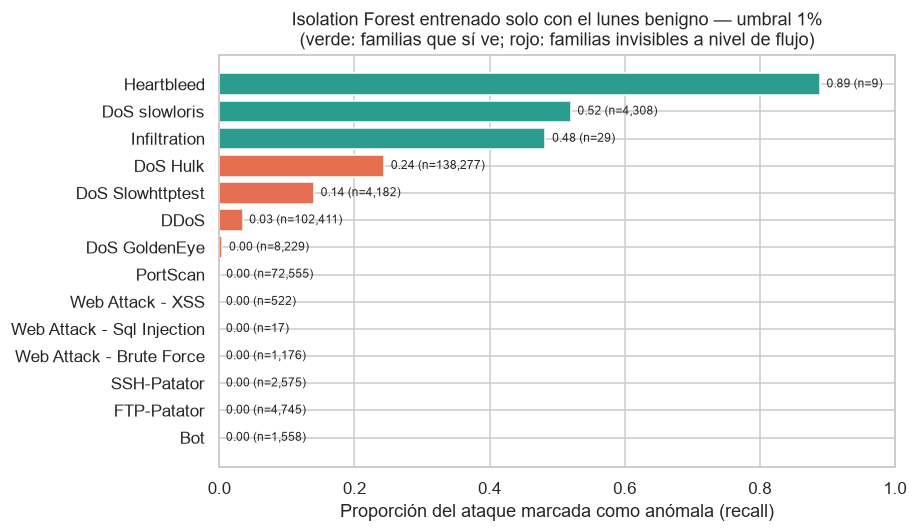

In [3]:
# Isolation Forest en el umbral de referencia (1%)
if_1 = recall.query("modelo == 'iforest' and umbral_pct == 1.0 and clase != 'TODOS LOS ATAQUES'")
if_1 = if_1.sort_values("recall")

fig, ax = plt.subplots(figsize=(8.5, 5))
colores = ["#2a9d8f" if r >= 0.4 else "#e76f51" for r in if_1["recall"]]
ax.barh(if_1["clase"], if_1["recall"], color=colores)
ax.set_xlabel("Proporción del ataque marcada como anómala (recall)")
ax.set_title("Isolation Forest entrenado solo con el lunes benigno — umbral 1%\n"
             "(verde: familias que sí ve; rojo: familias invisibles a nivel de flujo)")
ax.set_xlim(0, 1)
for i, (_, fila) in enumerate(if_1.iterrows()):
    ax.text(fila["recall"] + 0.01, i, f"{fila['recall']:.2f} (n={fila['n']:,})",
            va="center", fontsize=8)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "14_recall_no_supervisado.png", bbox_inches="tight")
plt.show()

**Lectura.** El detector separa los ataques en dos grupos:

- **Los que sí ve (flujos estructuralmente raros):** Heartbleed (0,89), DoS slowloris
  (0,52), Infiltration (0,48), y en parte DoS Hulk y Slowhttptest. Tiene sentido, porque
  son ataques cuyos flujos individuales ya son *anómalos por sí mismos* (una descarga
  gigante de memoria, conexiones que duran muchísimo). Además, **Heartbleed e
  Infiltration son justo las clases que el multiclase supervisado tuvo que excluir por
  falta de datos**, y aquí se detectan sin una sola etiqueta.
- **Los que no ve (0,000):** fuerza bruta (FTP/SSH-Patator), PortScan, ataques web y
  Bot. Esto también tiene una explicación: cada flujo de esos ataques es una conexión
  corta que se ve completamente normal, y lo anómalo está en el *conjunto* (miles de
  conexiones casi idénticas en poco tiempo). Un detector que mira los flujos de uno en
  uno no puede verlo.

El LOF confirma que los dos detectores se complementan: ve SSH-Patator (0,91) y algo de
PortScan (0,11), porque se basa en la densidad local en vez del aislamiento global, pero
pierde Heartbleed y los DoS lentos. Ninguno de los dos funciona como detector general.

## 2. El costo: falsas alarmas por día

In [4]:
tabla_fa = falsas.pivot_table(
    index=["modelo", "dia"], columns="umbral_pct", values="tasa_falsas_alarmas"
).round(4)
tabla_fa.columns = [f"umbral {c}%" for c in tabla_fa.columns]
tabla_fa

umbral 0.5%  \
modelo  dia                                                               
iforest Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         0.0913   
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISC...       0.0041   
        Friday-WorkingHours-Morning.pcap_ISCX.csv                0.0057   
        Thursday-WorkingHours-Afternoon-Infilteration.p...       0.0031   
        Thursday-WorkingHours-Morning-WebAttacks.pcap_I...       0.0043   
        Tuesday-WorkingHours.pcap_ISCX.csv                       0.0044   
        Wednesday-workingHours.pcap_ISCX.csv                     0.0133   
lof     Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         0.0051   
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISC...       0.0039   
        Friday-WorkingHours-Morning.pcap_ISCX.csv                0.0051   
        Thursday-WorkingHours-Afternoon-Infilteration.p...       0.0056   
        Thursday-WorkingHours-Morning-WebAttacks.pcap_I...       0.0044   
        Tuesday-WorkingHours.pcap_ISCX.csv                       0.0059   
        Wednesday-workingHours.pcap_ISCX.csv                     0.0054   

                                                            umbral 1.0%  \
modelo  dia                                                               
iforest Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         0.0958   
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISC...       0.0090   
        Friday-WorkingHours-Morning.pcap_ISCX.csv                0.0105   
        Thursday-WorkingHours-Afternoon-Infilteration.p...       0.0069   
        Thursday-WorkingHours-Morning-WebAttacks.pcap_I...       0.0088   
        Tuesday-WorkingHours.pcap_ISCX.csv                       0.0096   
        Wednesday-workingHours.pcap_ISCX.csv                     0.0183   
lof     Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         0.0091   
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISC...       0.0090   
        Friday-WorkingHours-Morning.pcap_ISCX.csv                0.0103   
        Thursday-WorkingHours-Afternoon-Infilteration.p...       0.0415   
        Thursday-WorkingHours-Morning-WebAttacks.pcap_I...       0.0103   
        Tuesday-WorkingHours.pcap_ISCX.csv                       0.0128   
        Wednesday-workingHours.pcap_ISCX.csv                     0.0113   

                                                            umbral 2.0%  
modelo  dia                                                              
iforest Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         0.1042  
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISC...       0.0179  
        Friday-WorkingHours-Morning.pcap_ISCX.csv                0.0203  
        Thursday-WorkingHours-Afternoon-Infilteration.p...       0.0147  
        Thursday-WorkingHours-Morning-WebAttacks.pcap_I...       0.0172  
        Tuesday-WorkingHours.pcap_ISCX.csv                       0.0192  
        Wednesday-workingHours.pcap_ISCX.csv                     0.0278  
lof     Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         0.0179  
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISC...       0.0228  
        Friday-WorkingHours-Morning.pcap_ISCX.csv                0.0251  
        Thursday-WorkingHours-Afternoon-Infilteration.p...       0.1549  
        Thursday-WorkingHours-Morning-WebAttacks.pcap_I...       0.0230  
        Tuesday-WorkingHours.pcap_ISCX.csv                       0.0331  
        Wednesday-workingHours.pcap_ISCX.csv                     0.0262

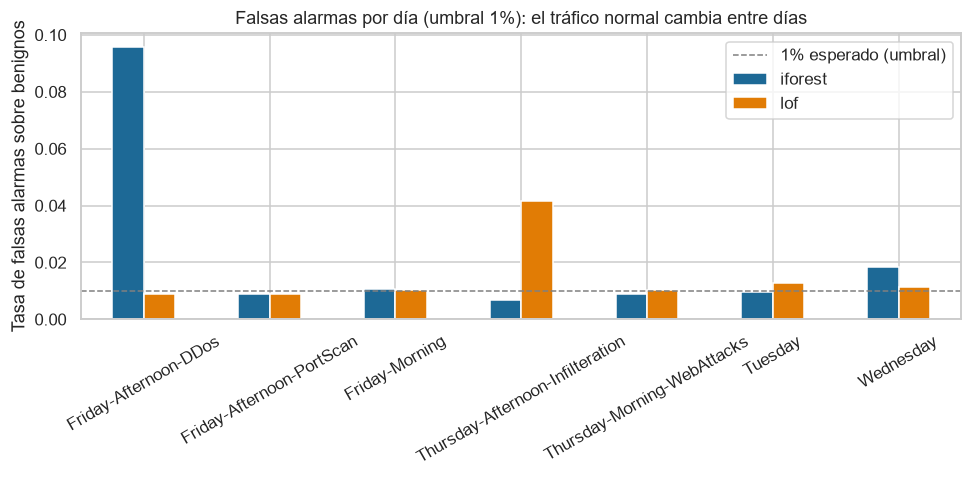

In [5]:
fa_1 = falsas.query("umbral_pct == 1.0").copy()
fa_1["dia_corto"] = (
    fa_1["dia"].str.replace(".pcap_ISCX.csv", "", regex=False)
    .str.replace("-WorkingHours", "", regex=False)
    .str.replace("-workingHours", "", regex=False)
)
piv = fa_1.pivot_table(index="dia_corto", columns="modelo", values="tasa_falsas_alarmas")

fig, ax = plt.subplots(figsize=(9, 4.5))
piv.plot.bar(ax=ax, color={"iforest": "#1d6996", "lof": "#e17c05"}, rot=30)
ax.axhline(0.01, color="gray", ls="--", lw=1, label="1% esperado (umbral)")
ax.set_ylabel("Tasa de falsas alarmas sobre benignos")
ax.set_xlabel("")
ax.set_title("Falsas alarmas por día (umbral 1%): el tráfico normal cambia entre días")
ax.legend(title="")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "15_falsas_alarmas_por_dia.png", bbox_inches="tight")
plt.show()

**Lectura.** Con el umbral del 1% (calibrado con el lunes), la mayoría de los días la
tasa de falsas alarmas queda cerca del 1% esperado (entre 0,7% y 1,8%), así que el
tráfico normal es bastante estable. Pero hay dos excepciones que muestran el riesgo de
este enfoque:

- El **viernes en la tarde (el archivo del DDoS)** el Isolation Forest llega a **9,6% de
  falsas alarmas** sobre el tráfico benigno, porque el tráfico normal de ese tramo se
  parece poco al del lunes (deriva temporal). Un analista recibiría ~7.300 alarmas falsas
  solo de ese tramo.
- El **jueves en la tarde** el LOF sube a 4,2%, porque su idea de densidad local es más
  sensible a las variaciones de cada día.

## 3. La distribución de scores: por qué ve lo que ve

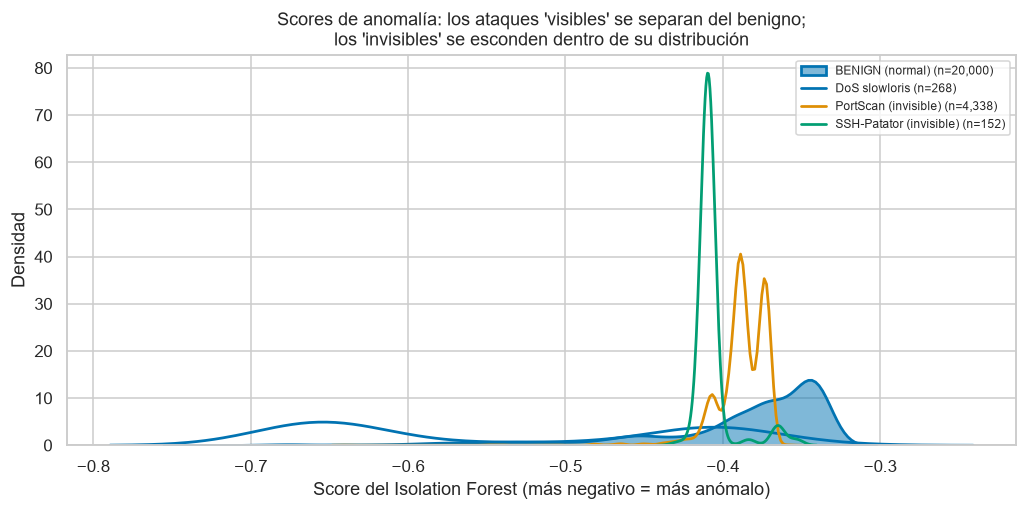

In [6]:
familias = {
    "BENIGN": "BENIGN (normal)",
    "Heartbleed": "Heartbleed",
    "Infiltration": "Infiltration",
    "DoS slowloris": "DoS slowloris",
    "PortScan": "PortScan (invisible)",
    "SSH-Patator": "SSH-Patator (invisible)",
}
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for clase, nombre in familias.items():
    sel = scores.loc[scores["clase"] == clase, "score_iforest"]
    if len(sel) < 5:
        continue
    sns.kdeplot(sel, ax=ax, label=f"{nombre} (n={len(sel):,})", fill=(clase == "BENIGN"),
                alpha=0.5 if clase == "BENIGN" else 1.0, lw=1.8, warn_singular=False)
ax.set_xlabel("Score del Isolation Forest (más negativo = más anómalo)")
ax.set_ylabel("Densidad")
ax.set_title("Scores de anomalía: los ataques 'visibles' se separan del benigno;\n"
             "los 'invisibles' se esconden dentro de su distribución")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "16_scores_no_supervisado.png", bbox_inches="tight")
plt.show()

## 4. Respuesta a la pregunta 3

**¿Un modelo entrenado solo con tráfico normal detecta ataques que nunca vio? Depende de
la familia del ataque, y la respuesta es que solo detecta algunos:**

| Conclusión | Evidencia |
|---|---|
| Como detector general, no funciona | 11,8% de recall global de ataques al 1% de falsas alarmas |
| Como red de seguridad para ataques estructuralmente raros, sí funciona | Heartbleed 0,89, Infiltration 0,48, slowloris 0,52, sin una sola etiqueta |
| Complementa justo donde el supervisado no llega | Heartbleed e Infiltration son las clases que se excluyeron del multiclase por falta de datos |
| Los ataques "camuflados" no se ven a nivel de flujo | Fuerza bruta, PortScan, web y Bot: recall de 0,000 (lo anómalo está en el conjunto de flujos) |
| La deriva temporal del tráfico normal tiene un costo real | 9,6% de falsas alarmas el viernes en la tarde frente a ~1% los demás días |

**Limitaciones documentadas:** (1) puede haber ataques sin etiquetar en el "benigno" del
lunes (por los errores de etiquetado que reporta la literatura), lo que se mitiga con el
umbral por cuantiles aunque no se puede descartar del todo; (2) el LOF usa una submuestra
de 50.000 flujos de entrenamiento por el costo computacional; (3) estos resultados son
sobre el conjunto de entrenamiento, y la evaluación final sobre el test se hace una única
vez en la fase final.